<a href="https://colab.research.google.com/github/Meghana-200502/NNDL/blob/main/CNN-parking%20system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.19.0
Images shape: (3000, 64, 64, 3)
BBox shape: (3000, 4)
Class labels shape: (3000,)


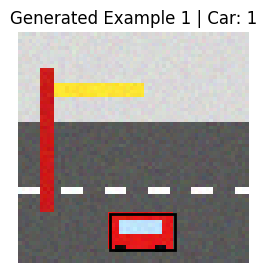

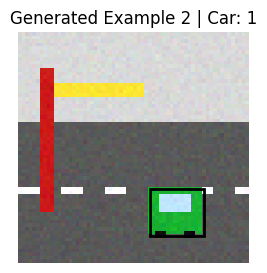

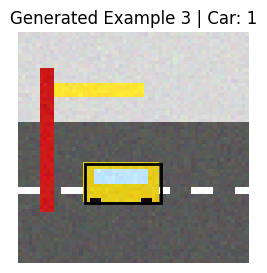

Train: (2100, 64, 64, 3)
Val  : (450, 64, 64, 3)
Test : (450, 64, 64, 3)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 8, 8, 128) │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_9[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 1)         │        129 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        516 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 421,957 (1.61 MB)

 Trainable params: 421,957 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 427ms/step - bbox_output_loss: 0.1043 - bbox_output_mse: 0.1042 - class_output_accuracy: 0.6890 - class_output_loss: 0.5957 - loss: 1.1172 - val_bbox_output_loss: 0.0966 - val_bbox_output_mse: 0.0942 - val_class_output_accuracy: 0.7111 - val_class_output_loss: 0.4477 - val_loss: 0.9061
Epoch 2/2
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 420ms/step - bbox_output_loss: 0.0569 - bbox_output_mse: 0.0571 - class_output_accuracy: 0.8971 - class_output_loss: 0.1699 - loss: 0.4564 - val_bbox_output_loss: 0.0098 - val_bbox_output_mse: 0.0098 - val_class_output_accuracy: 1.0000 - val_class_output_loss: 0.0047 - val_loss: 0.0538


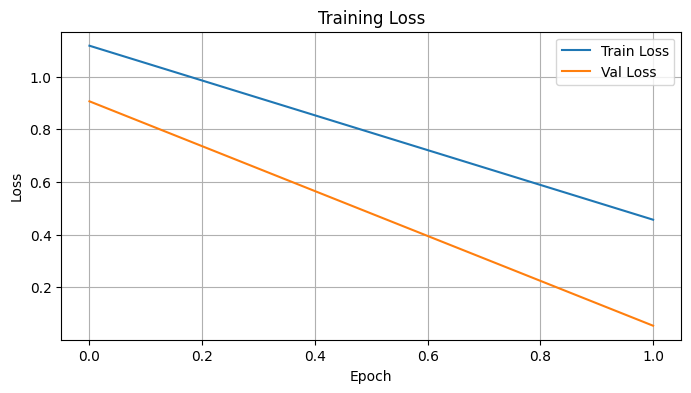

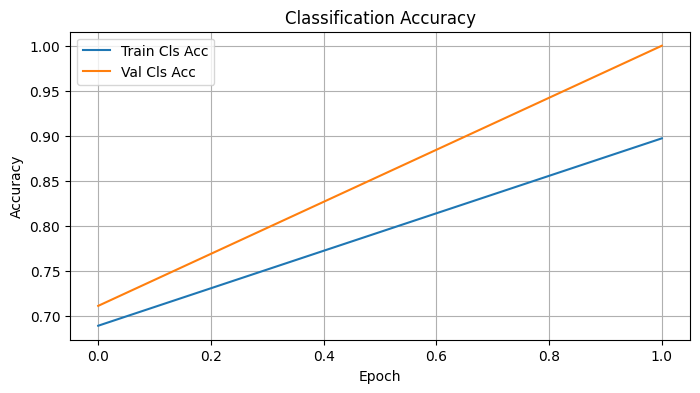

Test classification accuracy: 1.0
Mean IoU on detected cars: 0.20957926


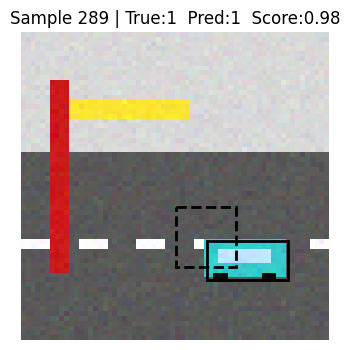

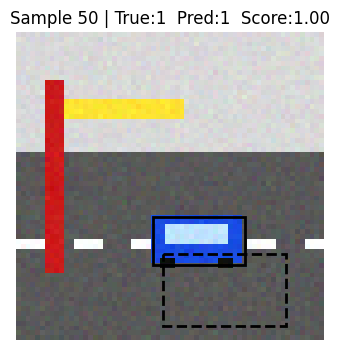

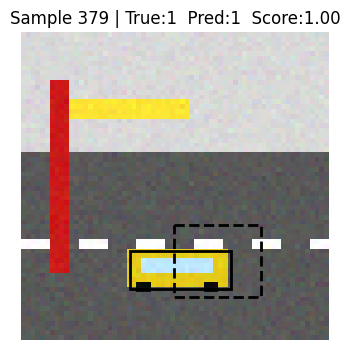

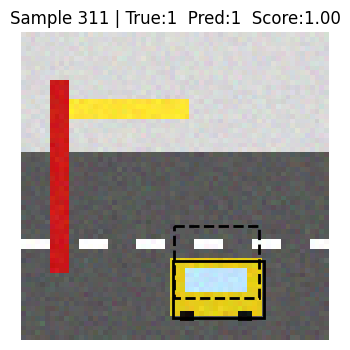

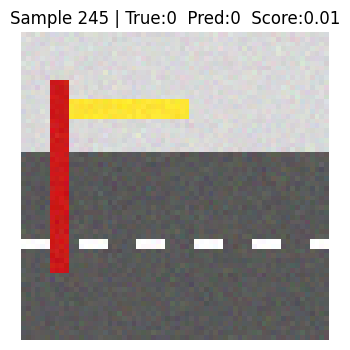

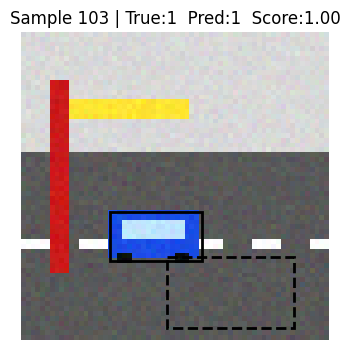

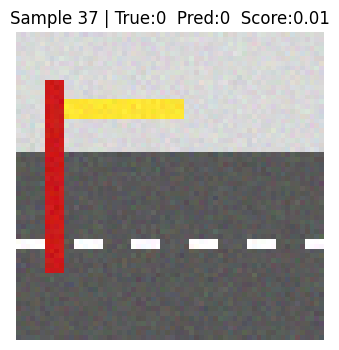

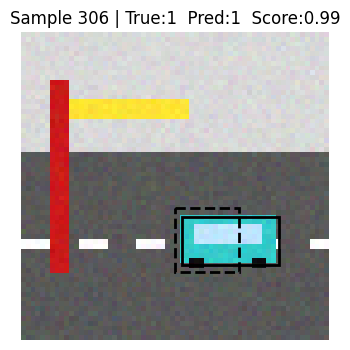

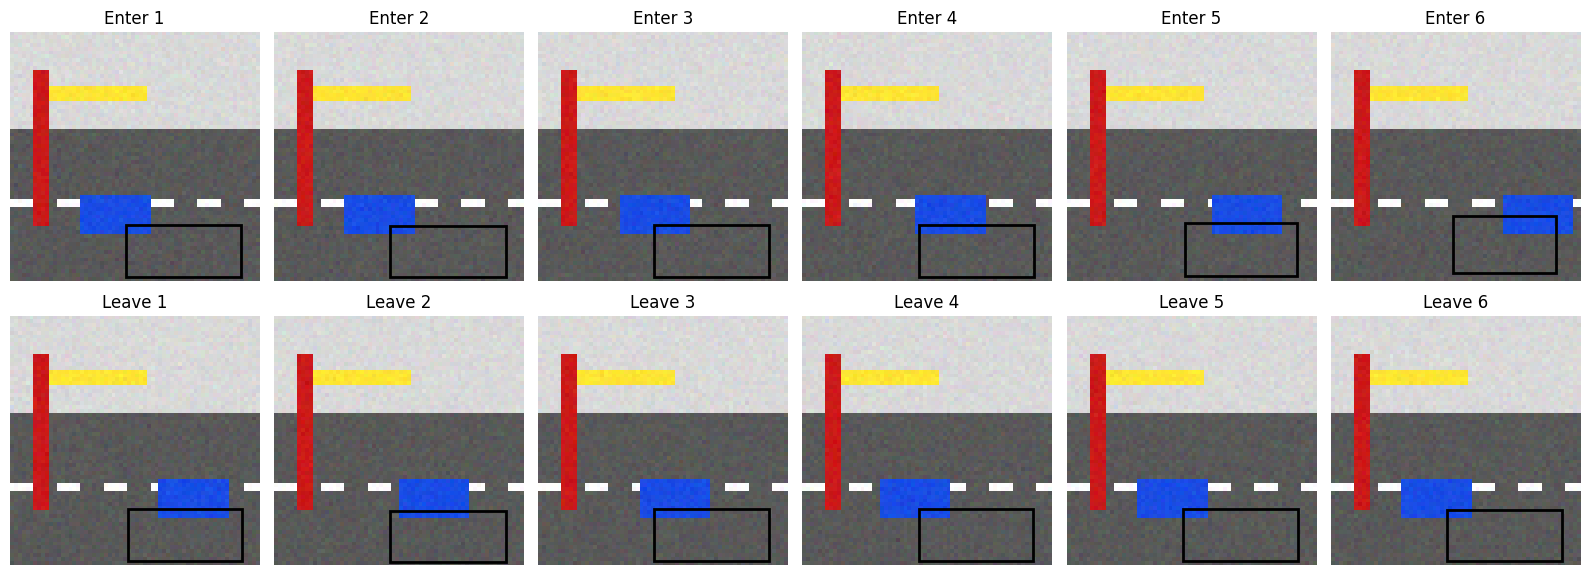

In [23]:
!pip -q install tensorflow matplotlib numpy scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

# ============================================================
# 2) Image settings
# ============================================================
IMG_H = 64
IMG_W = 64
IMG_C = 3

# Bounding box format:
# [x_min, y_min, x_max, y_max] normalized to [0, 1]

# ============================================================
# 3) Synthetic parking-gate image generator
# ============================================================
def draw_rectangle(img, x1, y1, x2, y2, color):
    img[y1:y2, x1:x2, :] = color
    return img

def add_noise(img, noise_level=0.03):
    noise = np.random.normal(0, noise_level, img.shape)
    img = img + noise
    return np.clip(img, 0, 1)

def generate_background():
    img = np.ones((IMG_H, IMG_W, IMG_C), dtype=np.float32) * 0.85

    # road
    img[25:64, :, :] = np.array([0.35, 0.35, 0.35], dtype=np.float32)

    # lane markings
    for x in range(0, IMG_W, 12):
        img[43:45, x:x+6, :] = np.array([1.0, 1.0, 1.0], dtype=np.float32)

    # gate pole
    img[10:50, 6:10, :] = np.array([0.8, 0.1, 0.1], dtype=np.float32)

    # barrier
    img[14:18, 10:35, :] = np.array([1.0, 0.9, 0.2], dtype=np.float32)

    return img

def generate_car_color():
    colors = [
        [0.1, 0.3, 0.9],   # blue
        [0.9, 0.1, 0.1],   # red
        [0.1, 0.7, 0.2],   # green
        [0.9, 0.8, 0.1],   # yellow
        [0.6, 0.2, 0.8],   # purple
        [0.2, 0.8, 0.8],   # cyan
    ]
    return np.array(colors[np.random.randint(len(colors))], dtype=np.float32)

def generate_sample(car_present=True):
    img = generate_background()

    if car_present:
        car_w = np.random.randint(14, 22)
        car_h = np.random.randint(8, 14)

        x1 = np.random.randint(18, IMG_W - car_w - 4)
        y1 = np.random.randint(30, IMG_H - car_h - 3)
        x2 = x1 + car_w
        y2 = y1 + car_h

        car_color = generate_car_color()
        img = draw_rectangle(img, x1, y1, x2, y2, car_color)

        # windows
        wx1 = x1 + 3
        wx2 = min(x2 - 3, x1 + car_w - 2)
        wy1 = y1 + 2
        wy2 = min(y2 - 2, y1 + car_h // 2 + 1)
        img = draw_rectangle(img, wx1, wy1, wx2, wy2, np.array([0.75, 0.9, 1.0], dtype=np.float32))

        # wheels
        img[max(y2-1, 0):min(y2+1, IMG_H), max(x1+2, 0):min(x1+5, IMG_W), :] = 0.05
        img[max(y2-1, 0):min(y2+1, IMG_H), max(x2-5, 0):min(x2-2, IMG_W), :] = 0.05

        bbox = np.array([x1 / IMG_W, y1 / IMG_H, x2 / IMG_W, y2 / IMG_H], dtype=np.float32)
        label = 1.0
    else:
        bbox = np.array([0, 0, 0, 0], dtype=np.float32)
        label = 0.0

    img = add_noise(img, noise_level=0.02)
    return img.astype(np.float32), bbox, label

# ============================================================
# 4) Create synthetic dataset
# ============================================================
def create_dataset(n_samples=3000):
    images = []
    bboxes = []
    labels = []

    for _ in range(n_samples):
        car_present = np.random.rand() > 0.3  # 70% positive, 30% negative
        img, bbox, label = generate_sample(car_present=car_present)
        images.append(img)
        bboxes.append(bbox)
        labels.append(label)

    return np.array(images), np.array(bboxes), np.array(labels)

X, y_bbox, y_cls = create_dataset(n_samples=3000)

print("Images shape:", X.shape)
print("BBox shape:", y_bbox.shape)
print("Class labels shape:", y_cls.shape)

# ============================================================
# 5) Show some generated examples
# ============================================================
def plot_sample(img, bbox=None, title="Sample"):
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    ax = plt.gca()

    if bbox is not None and np.sum(bbox) > 0:
        x1, y1, x2, y2 = bbox
        x1 *= IMG_W
        x2 *= IMG_W
        y1 *= IMG_H
        y2 *= IMG_H

        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                             fill=False, linewidth=2)
        ax.add_patch(rect)

    plt.title(title)
    plt.axis("off")
    plt.show()

for i in range(3):
    plot_sample(X[i], y_bbox[i], f"Generated Example {i+1} | Car: {int(y_cls[i])}")

# ============================================================
# 6) Train / validation / test split
# ============================================================
X_train, X_temp, y_bbox_train, y_bbox_temp, y_cls_train, y_cls_temp = train_test_split(
    X, y_bbox, y_cls, test_size=0.3, random_state=42
)

X_val, X_test, y_bbox_val, y_bbox_test, y_cls_val, y_cls_test = train_test_split(
    X_temp, y_bbox_temp, y_cls_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

# ============================================================
# 7) Build CNN-based object detector
#    Two outputs:
#    - class_output: car present / absent
#    - bbox_output : bounding box coordinates
# ============================================================
inputs = layers.Input(shape=(IMG_H, IMG_W, IMG_C))

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

class_output = layers.Dense(1, activation="sigmoid", name="class_output")(x)
bbox_output = layers.Dense(4, activation="sigmoid", name="bbox_output")(x)

model = models.Model(inputs=inputs, outputs=[class_output, bbox_output])

model.compile(
    optimizer="adam",
    loss={
        "class_output": "binary_crossentropy",
        "bbox_output": "mse"
    },
    loss_weights={
        "class_output": 1.0,
        "bbox_output": 5.0
    },
    metrics={
        "class_output": ["accuracy"],
        "bbox_output": ["mse"]
    }
)

model.summary()

# ============================================================
# 8) Train
# ============================================================
history = model.fit(
    X_train,
    {"class_output": y_cls_train, "bbox_output": y_bbox_train},
    validation_data=(
        X_val,
        {"class_output": y_cls_val, "bbox_output": y_bbox_val}
    ),
    epochs=2,
    batch_size=32,
    verbose=1
)

# ============================================================
# 9) Plot training curves
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["class_output_accuracy"], label="Train Cls Acc")
plt.plot(history.history["val_class_output_accuracy"], label="Val Cls Acc")
plt.title("Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 10) Predict on test set
# ============================================================
pred_cls, pred_bbox = model.predict(X_test, verbose=0)
pred_cls_label = (pred_cls.flatten() > 0.5).astype(int)

# ============================================================
# 11) IoU helper for bounding box quality
# ============================================================
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - inter_area + 1e-8
    return inter_area / union

ious = []
for i in range(len(X_test)):
    if y_cls_test[i] == 1 and pred_cls_label[i] == 1:
        iou = compute_iou(y_bbox_test[i], pred_bbox[i])
        ious.append(iou)

print("Test classification accuracy:", np.mean(pred_cls_label == y_cls_test))
if len(ious) > 0:
    print("Mean IoU on detected cars:", np.mean(ious))
else:
    print("No positive detections to compute IoU.")

# ============================================================
# 12) Visualization: true and predicted bounding boxes
# ============================================================
def show_prediction(img, true_bbox, true_cls, pred_bbox, pred_cls_score, idx=None):
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    ax = plt.gca()

    # True box in green
    if true_cls == 1 and np.sum(true_bbox) > 0:
        tx1, ty1, tx2, ty2 = true_bbox
        tx1 *= IMG_W
        tx2 *= IMG_W
        ty1 *= IMG_H
        ty2 *= IMG_H
        rect_true = plt.Rectangle((tx1, ty1), tx2-tx1, ty2-ty1,
                                  fill=False, linewidth=2, linestyle='-')
        ax.add_patch(rect_true)

    # Predicted box in red if confidence is enough
    if pred_cls_score > 0.5:
        px1, py1, px2, py2 = pred_bbox
        px1 *= IMG_W
        px2 *= IMG_W
        py1 *= IMG_H
        py2 *= IMG_H
        rect_pred = plt.Rectangle((px1, py1), px2-px1, py2-py1,
                                  fill=False, linewidth=2, linestyle='--')
        ax.add_patch(rect_pred)

    title = f"True:{int(true_cls)}  Pred:{int(pred_cls_score > 0.5)}  Score:{pred_cls_score:.2f}"
    if idx is not None:
        title = f"Sample {idx} | " + title

    plt.title(title)
    plt.axis("off")
    plt.show()

# show random predictions
sample_indices = np.random.choice(len(X_test), 8, replace=False)
for idx in sample_indices:
    show_prediction(
        X_test[idx],
        y_bbox_test[idx],
        y_cls_test[idx],
        pred_bbox[idx],
        pred_cls[idx][0],
        idx=idx
    )

# ============================================================
# 13) Demonstrate a few cars entering and leaving gate
# ============================================================
# Simulate consecutive frames with different x positions
def generate_motion_frames(num_frames=6, entering=True):
    frames = []
    boxes = []

    for i in range(num_frames):
        img = generate_background()

        car_w = 18
        car_h = 10
        y1 = 42
        y2 = y1 + car_h

        if entering:
            x1 = 5 + i * 8
        else:
            x1 = 38 - i * 6

        x1 = max(18, min(x1, IMG_W - car_w - 2))
        x2 = x1 + car_w

        car_color = np.array([0.1, 0.3, 0.9], dtype=np.float32)
        img = draw_rectangle(img, x1, y1, x2, y2, car_color)
        img = add_noise(img, 0.02)

        bbox = np.array([x1 / IMG_W, y1 / IMG_H, x2 / IMG_W, y2 / IMG_H], dtype=np.float32)

        frames.append(img)
        boxes.append(bbox)

    return np.array(frames), np.array(boxes)

frames_enter, _ = generate_motion_frames(entering=True)
frames_leave, _ = generate_motion_frames(entering=False)

pred_cls_enter, pred_bbox_enter = model.predict(frames_enter, verbose=0)
pred_cls_leave, pred_bbox_leave = model.predict(frames_leave, verbose=0)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))

for i in range(6):
    axes[0, i].imshow(frames_enter[i])
    axes[0, i].set_title(f"Enter {i+1}")
    axes[0, i].axis("off")

    if pred_cls_enter[i][0] > 0.5:
        x1, y1, x2, y2 = pred_bbox_enter[i]
        x1 *= IMG_W; x2 *= IMG_W; y1 *= IMG_H; y2 *= IMG_H
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        axes[0, i].add_patch(rect)

for i in range(6):
    axes[1, i].imshow(frames_leave[i])
    axes[1, i].set_title(f"Leave {i+1}")
    axes[1, i].axis("off")

    if pred_cls_leave[i][0] > 0.5:
        x1, y1, x2, y2 = pred_bbox_leave[i]
        x1 *= IMG_W; x2 *= IMG_W; y1 *= IMG_H; y2 *= IMG_H
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        axes[1, i].add_patch(rect)

plt.tight_layout()
plt.show()